In [1]:
using CSV
using DataFrames
using CairoMakie
using LsqFit
using Statistics

Probe 1


In [2]:


#Daten aus Datei nehmen
df = CSV.read("Messdaten_Pulverdiffraktonomie/Probe1_Messdaten.xye", DataFrame, delim=' ', ignorerepeated=true, 
skipto=2, header=["zwei_theta", "I", "ΔI"])

zwei_θ = df.zwei_theta
I = df.I
ΔI = df.ΔI;



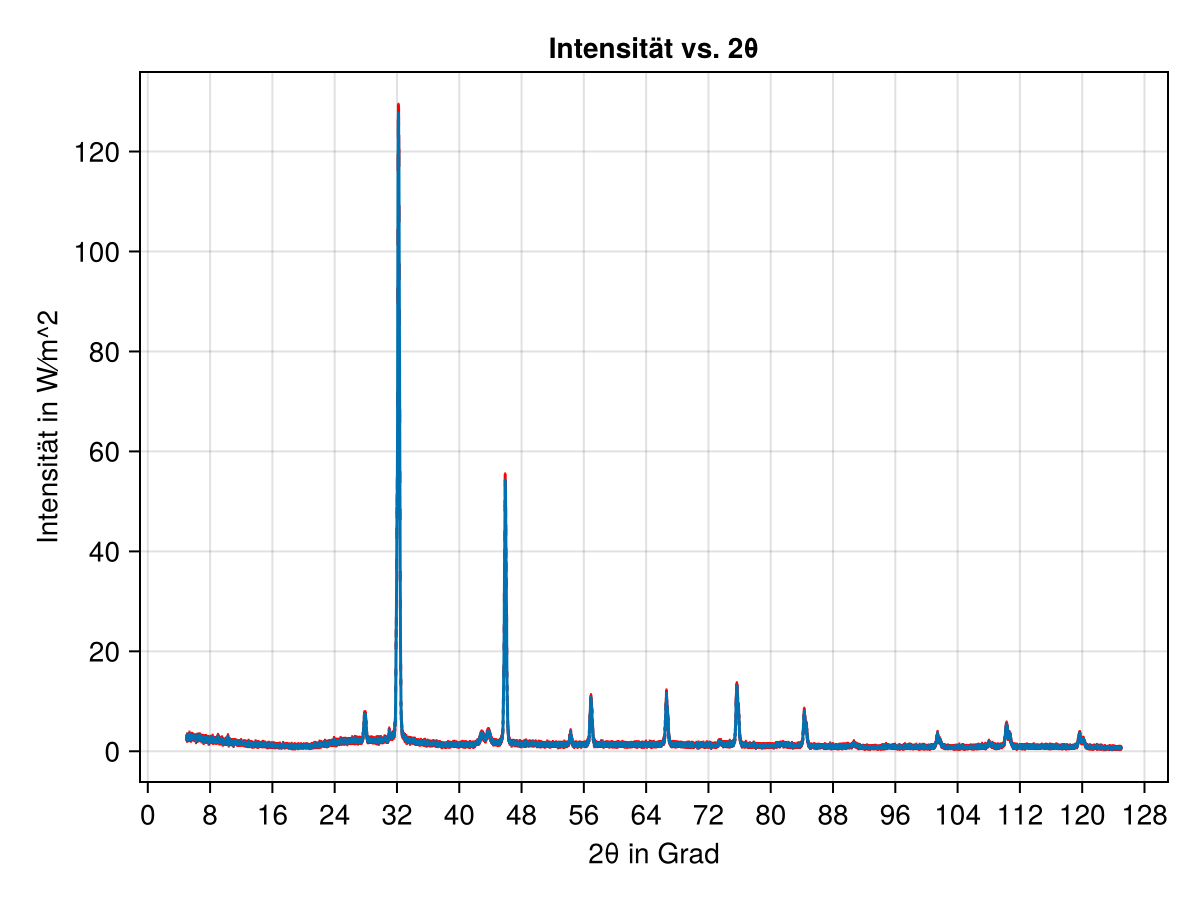

In [3]:
#Intensität vs 2theta
fig, ax, eb = errorbars(zwei_θ, I, ΔI, color = :red, whiskerwidth = 1)
scatterlines!(ax, zwei_θ, I, markersize = 2)

ax.xticks = LinearTicks(20)
ax.yticks = LinearTicks(8)
ax.title = "Intensität vs. 2θ"
ax.xlabel = "2θ in Grad"
ax.ylabel = "Intensität in W⁄m^2"
fig

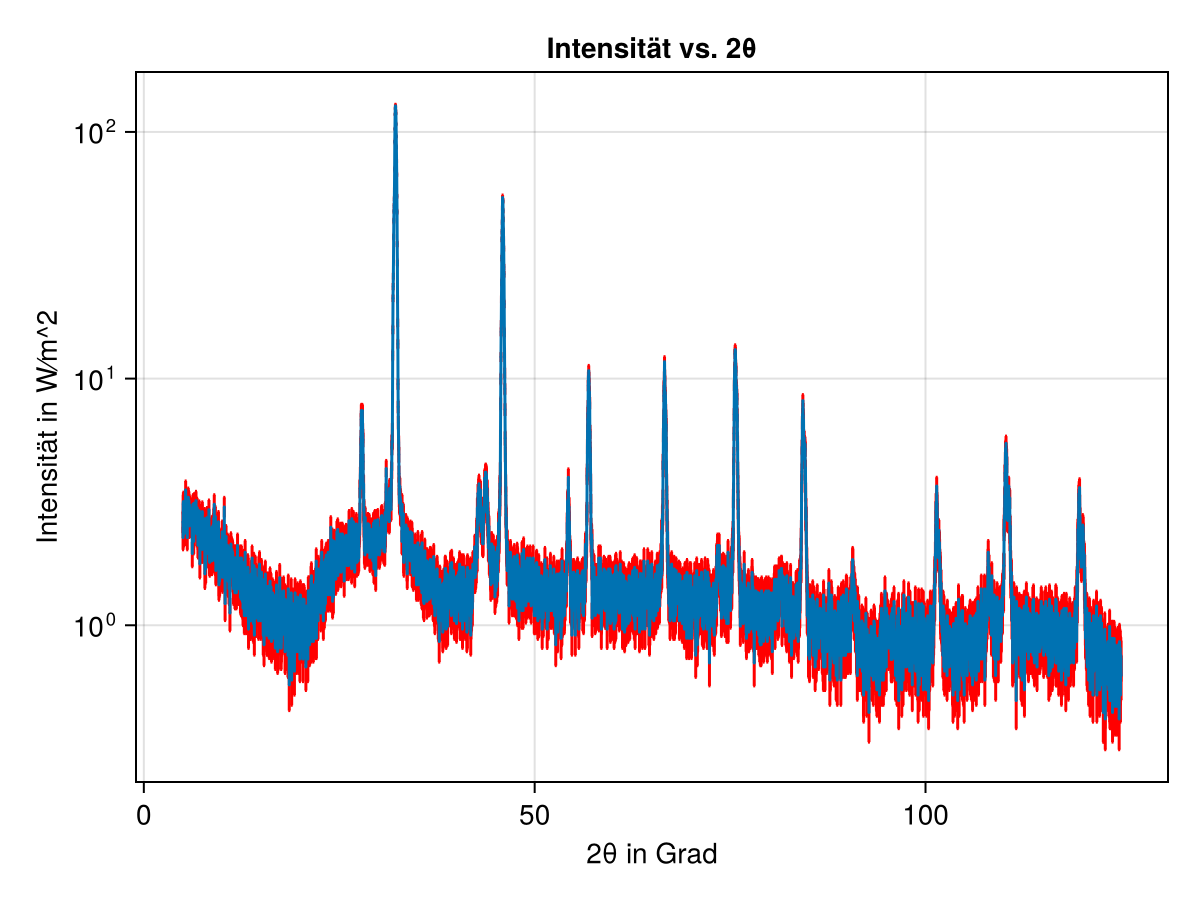

In [4]:
#Intensität mit log-skala
fig, ax, eb = errorbars(zwei_θ, I, ΔI, color = :red, whiskerwidth = 1)
scatterlines!(ax, zwei_θ, I, markersize = 2)


ax.yscale = log10
#ax.xscale = log10
ax.title = "Intensität vs. 2θ"
ax.xlabel = "2θ in Grad"
ax.ylabel = "Intensität in W⁄m^2"
fig



In [5]:
#Fit des Plotts ohne log-skala am ersten peak

#Vector mit Parametern der Kurven, Amplitude, position max, Breite/standartabweichung
#x ist 2θ, also array
#p[3],p[6]=Breite; p[2],p[5]=Lage Max.
#p[7] konstanter Hintergrund zum verschieben der Kurven nach oben sd. kurve fit nicht null wird

function doppel_gauß(x, p)
    gauß1 = p[1] .* exp.(-(x .-p[2]).^2 ./ (2 .*p[3]^2))
    gauß2 = p[4] .* exp.(-(x .-p[5]).^2 ./ (2 .*p[6]^2))
    return gauß1 .+ gauß2 .+p[7]
end

#Startwerte p0 anhan des original Plots. Aus Atomphysik flgt aus der anzahl an e-Zuständen pro Unterschale dass das 
#Verhältnis der Intensitäten der Wellenlängen 2:1 stehen
p0 = [120, 32.1, 0.1, 60, 32.15, 0.1, 1]

#Werte einschränken, damit Fit zentriert um den ersten peak anfängt
bereich = (zwei_θ .> 31.5) .& (zwei_θ .< 33.0)
x_fit = zwei_θ[bereich]
y_fit = I[bereich]

#Fit berechnen
fit_ergebnis = curve_fit(doppel_gauß, x_fit, y_fit, p0)

#Parameter rauslesen für nächsten schritt
parameter = coef(fit_ergebnis)

println("Optimale Parameter für das Dublett:")
println("Peak 1 (Kα1): Amplitude = $(parameter[1]), pos_max = $(parameter[2])°")
println("Peak 2 (Kα2): Amplitude = $(parameter[4]), pos_max = $(parameter[5])°")


Optimale Parameter für das Dublett:
Peak 1 (Kα1): Amplitude = 57.68340765378828, pos_max = 32.17328055543175°
Peak 2 (Kα2): Amplitude = 68.65077799692232, pos_max = 32.217744470727425°


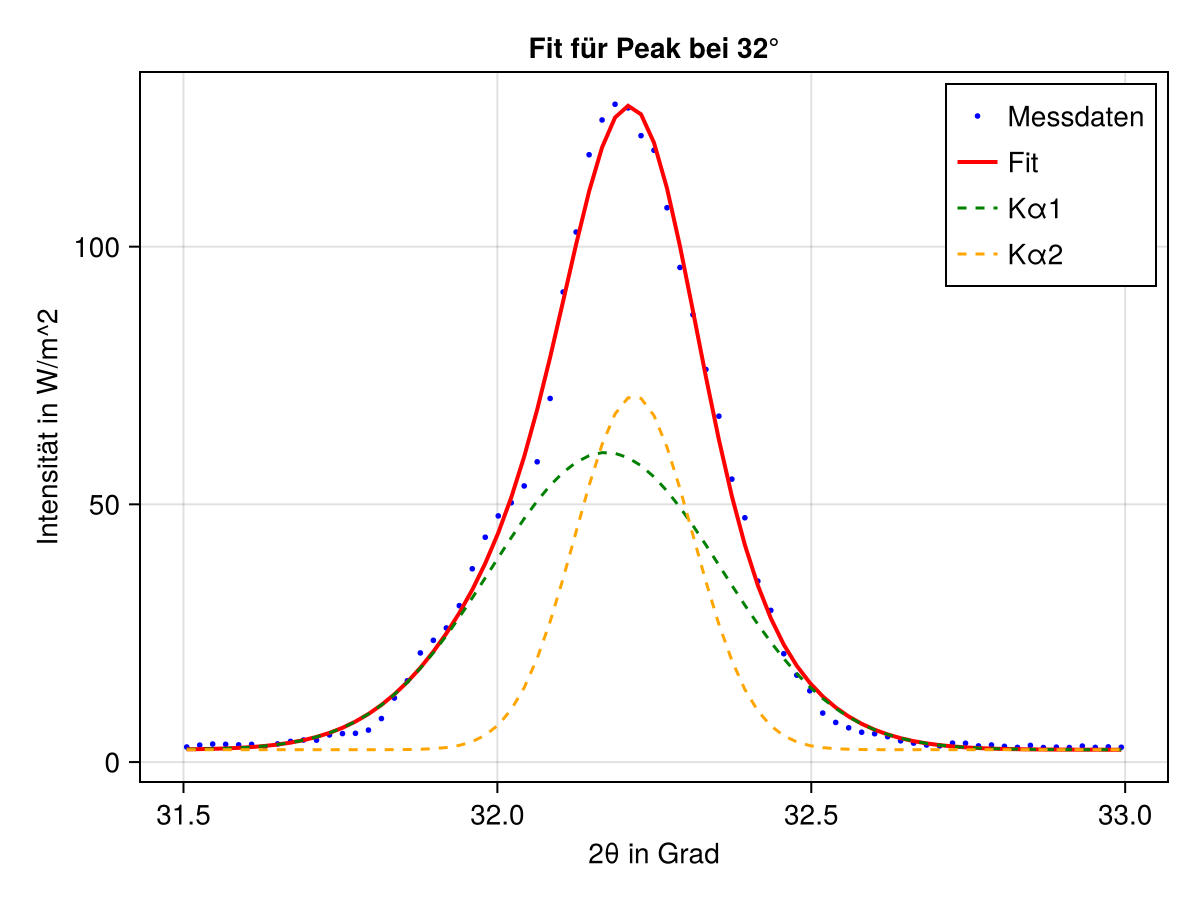

In [6]:
#fir über origanl plotten lassen am ersten peak
fig = Figure()
ax = Axis(fig[1,1], title="Fit für Peak bei 32°", xlabel="2θ in Grad", ylabel="Intensität in W/m^2")

#Originale Datenpunkte im Bereich um ersten peak
scatter!(ax, x_fit, y_fit, color=:blue, markersize=4, label="Messdaten")

#Gefittete Gesamtkurve berechnen
y_modell = doppel_gauß(x_fit, parameter)
lines!(ax, x_fit, y_modell, color=:red, linewidth=2, label="Fit")

#Die beiden einzelnen mathematischen Peaks anzeigen, aus denen sich die Kurve zusammensetzt
lines!(ax, x_fit, parameter[1] .* exp.(-((x_fit .- parameter[2]).^2) ./ (2 .* parameter[3]^2)) .+ parameter[7], color=:green, linestyle=:dash, label="Kα1")
lines!(ax, x_fit, parameter[4] .* exp.(-((x_fit .- parameter[5]).^2) ./ (2 .* parameter[6]^2)) .+ parameter[7], color=:orange, linestyle=:dash, label="Kα2")

axislegend(ax)
fig

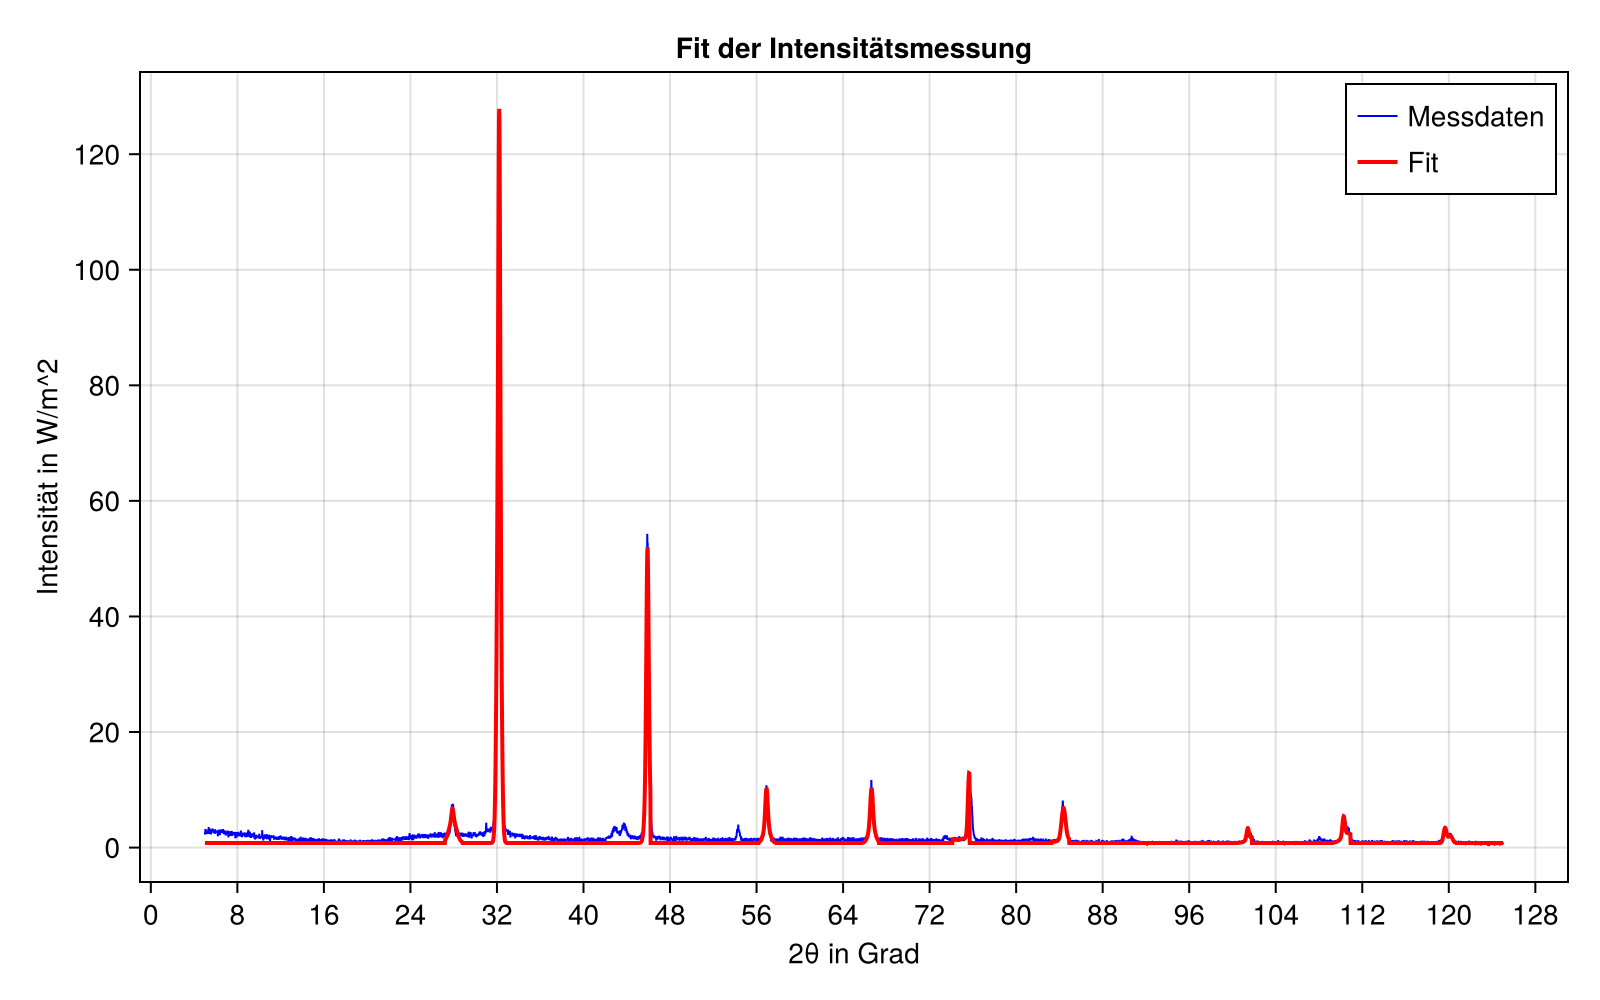

In [ ]:
#Ein noch mehr von Gemini geschriebene r Code
#Es wird für jeden Peak ein fit gemacht die dann nacher zusammen gefügt werden zu einem Gesantfit

# 1. Das physikalische Modell für ein einzelnes Dublett, mit festem 2:1 Verhältnis der Intensitäten
# p = [Amp1, Max1, Breite1, Max2, Breite2]
function doppel_gauß_einzeln(x, p)
    g1 = p[1] .* exp.(-(x .- p[2]).^2 ./ (2 .* p[3]^2))
    g2 = (p[1] / 2) .* exp.(-(x .- p[4]).^2 ./ (2 .* p[5]^2))
    return g1 .+ g2
end

# 1. Liste an allen ungefähren Positionen der peaks die gefittet werden sollen
peak_zentren = [28, 32.1, 45.2, 57.0, 66.5, 74.9, 84.1, 101.0, 110.1, 120.0] 

#Fester Wert für den Boden
fit_ergebnisse = []
untergrund_fest = 0.8 

# Jeden Peak einzeln fitten in einer Schleife
for zentrum in peak_zentren
    # Für den schwierigen Peak bei 45.2 nutzen wir ein etwas weiteres Fenster,
    # um den gesamten Ausläufer mitzunehmen.
    f_breite = (zentrum == 45.2) ? 1.0 : 0.8
    bereich = (zwei_θ .> zentrum - f_breite) .& (zwei_θ .< zentrum + f_breite)
    
    x_sub = zwei_θ[bereich]
    y_sub = I[bereich]
    
    if isempty(x_sub) continue end
    
    # Standard-Startwerte
    amp_start = max(0.1, maximum(y_sub) - untergrund_fest)
    p0 = [amp_start, zentrum, 0.05, zentrum + 0.04, 0.05] 
    
    # Spezialbehandlung für den Problempeak bei 45.2° ohne starre Box-Grenzen,
    # aber mit extrem defensiven Startwerten für die Peak-Breite (sigma)
    if zentrum == 45.2
        # Wir geben ihm eine realistischere, etwas größere Startbreite (0.08 statt 0.03)
        # und setzen das Zentrum von Kα1 exakt auf den höchsten Punkt im Teilfenster
        x_max_lokal = x_sub[argmax(y_sub)]
        p0 = [maximum(y_sub) - untergrund_fest, x_max_lokal, 0.08, x_max_lokal + 0.05, 0.08]
    end
    
    model_lokal(x, p) = doppel_gauß_einzeln(x, p) .+ untergrund_fest
    
    try
        if zentrum == 45.2
            # Wir nutzen etwas großzügigere Grenzen, die nur das Ausbrechen ins Unendliche verhindern,
            # aber der Form (Breite) vollkommene Freiheit lassen:
            untere_grenze = [1.0,  44.5,  0.01,  44.5,  0.01]
            obere_grenze  = [200.0, 46.0,  0.3,   46.0,  0.3]
            
            fit = curve_fit(model_lokal, x_sub, y_sub, p0, lower=untere_grenze, upper=obere_grenze)
        else
            fit = curve_fit(model_lokal, x_sub, y_sub, p0)
        end
        
        p_opt = coef(fit)
        
        if p_opt[1] > 1.0 
            push!(fit_ergebnisse, (params=p_opt, bereich=bereich))
        end
    catch e
        println("Fit fehlgeschlagen bei Zentrum $zentrum")
    end
end

# 4. Gesamtkurve zusammensetzen
y_gesamt = fill(untergrund_fest, length(zwei_θ))

for fit in fit_ergebnisse
    y_peak = doppel_gauß_einzeln(zwei_θ, fit.params)
    y_peak[.!fit.bereich] .= 0.0
    global y_gesamt += y_peak
end

# 5. Plotten
fig = Figure(size = (800, 500))
ax = Axis(fig[1, 1], 
    title = "Fit der Intensitätsmessung",
    xlabel = "2θ in Grad",
    ylabel = "Intensität in W/m^2"
)

lines!(ax, zwei_θ, I, color = :blue, linewidth = 1, label = "Messdaten")
lines!(ax, zwei_θ, y_gesamt, color = :red, linewidth = 2, label = "Fit")

ax.xticks = LinearTicks(20)
ax.yticks = LinearTicks(8)

axislegend(ax)
fig
